## Librerias


In [ ]:
import pandas as pd
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

## Carga, limpieza y encoder de datos

In [ ]:


df = pd.read_csv("/content/datos_telecomX.csv")

In [ ]:
df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0,0,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,1,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,0,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [ ]:
#Calculamos el porcentaje de churn
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0,0,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,1,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,0,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [ ]:
#Encoder de variables

categorical_cols = [
    "phone_MultipleLines",
    "internet_InternetService",
    "internet_OnlineSecurity",
    "internet_OnlineBackup",
    "internet_DeviceProtection",
    "internet_TechSupport",
    "internet_StreamingTV",
    "internet_StreamingMovies",
    "account_Contract",
    "account_PaymentMethod",
]

one_hot_encoder = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    remainder="passthrough"
)

datos = one_hot_encoder.fit_transform(df)

df = pd.DataFrame(
    datos,
    columns=one_hot_encoder.get_feature_names_out(),
    index=df.index
)

In [ ]:
# Modificamos los nombres de las variables y separamos la variable objetivo
df.columns = df.columns.str.replace("onehotencoder__", "", regex=False)
df.columns = df.columns.str.replace("remainder__", "", regex=False)
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
# Verificamos que todas las variables sean numericas
#X.dtypes

## Correlación y Selección de Variables

Churn                                              1.000000
account_Contract_Month-to-month                    0.404565
internet_OnlineSecurity_No                         0.342235
internet_TechSupport_No                            0.336877
internet_InternetService_Fiber optic               0.307463
account_PaymentMethod_Electronic check             0.301455
internet_OnlineBackup_No                           0.267595
internet_DeviceProtection_No                       0.252056
Cuentas_Diarias                                    0.192858
account_Charges_Monthly                            0.192858
account_PaperlessBilling                           0.191454
customer_SeniorCitizen                             0.150541
internet_StreamingMovies_No                        0.130920
internet_StreamingTV_No                            0.128435
internet_StreamingTV_Yes                           0.063254
internet_StreamingMovies_Yes                       0.060860
phone_MultipleLines_Yes                 

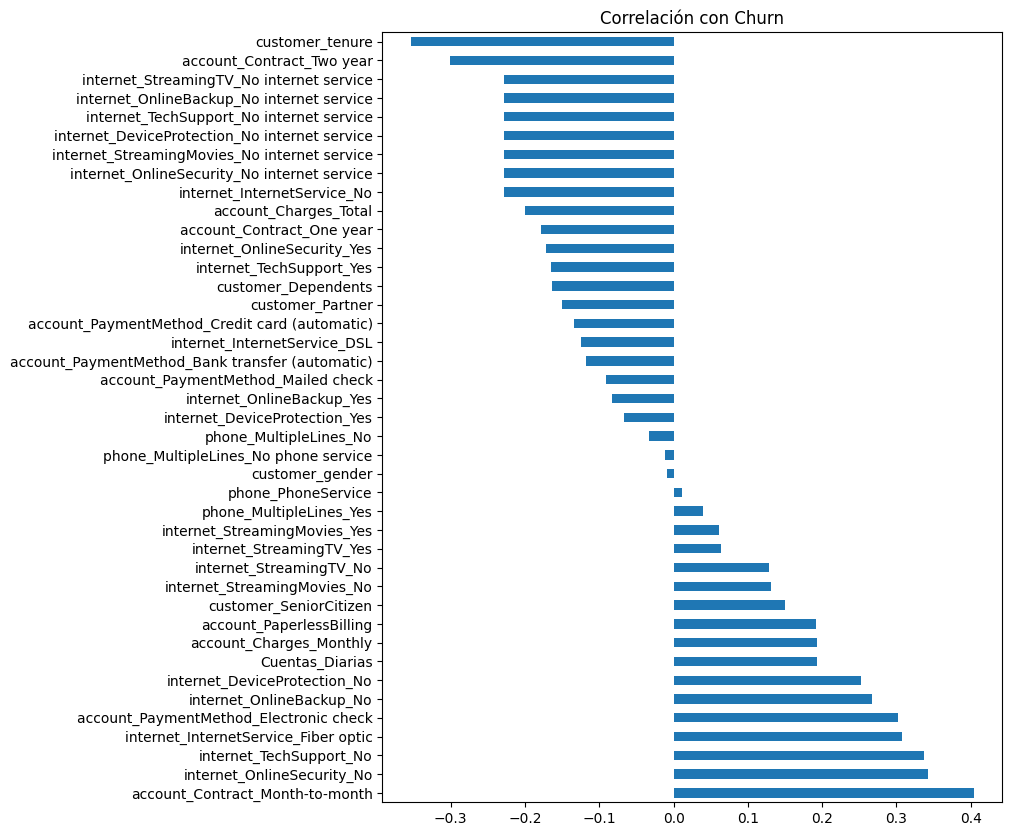

In [ ]:
# Calculamos la correlacion de las distintas variables con la variable objetivo y graficamos
corr_churn = df.corr()["Churn"].sort_values(ascending=False)
print(corr_churn)

corr_churn.drop("Churn").plot(kind="barh", figsize=(8,10))
plt.title("Correlación con Churn")
plt.show()

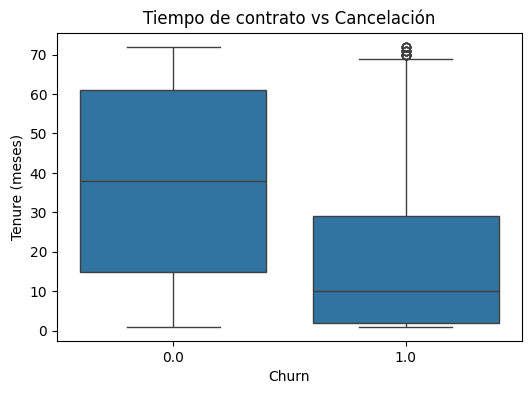

In [ ]:
# Graficamos el tiempo de contrato vs Cancelación
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Tenure (meses)")

plt.show()

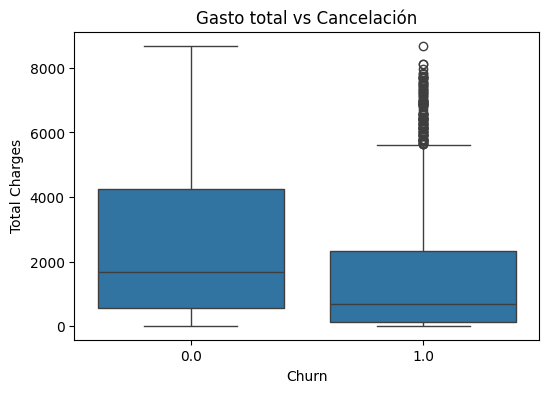

In [ ]:
#Graficamos el gasto total vs Cancelación
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="account_Charges_Total", data=df)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

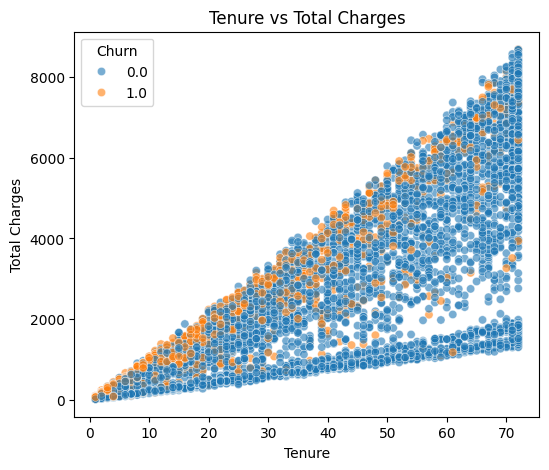

In [ ]:
# Graficamos Tenure vs total charges
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="customer_tenure",
    y="account_Charges_Total",
    hue="Churn",
    data=df,
    alpha=0.6
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.show()

In [ ]:
# Armamos los conjuntos de entrenamiento, test y balanceamos clases
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
# Estandarizamos para los modelos que lo necesitan

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelos

### Logistic Regression

[[757 276]
 [ 77 297]]
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



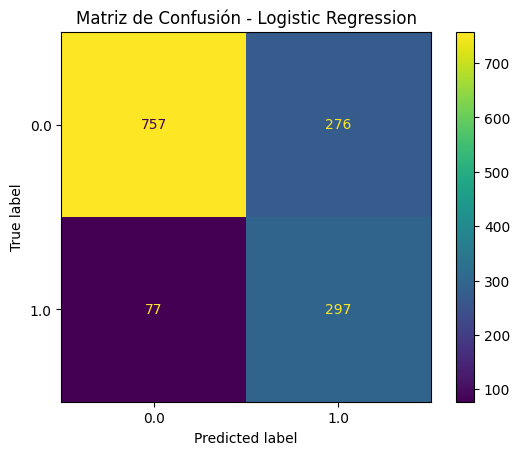

In [ ]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

pred_log = log_reg.predict(X_test_scaled)

print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

ConfusionMatrixDisplay.from_predictions(y_test, pred_log)
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

In [ ]:
# Utilizamos regresion logistica en las variables que mas correlacion tienen con churn
corr = df.corr()["Churn"].abs().sort_values(ascending=False)

top_features = corr.index[1:16]

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)
valid_features = [c for c in top_features if c in X_train.columns]

print(valid_features)
X_train_corr = X_train_scaled_df[valid_features].copy()
X_test_corr = X_test_scaled_df[valid_features].copy()
from sklearn.linear_model import LogisticRegression

log_corr = LogisticRegression(max_iter=1000)

log_corr.fit(X_train_corr, y_train)

pred = log_corr.predict(X_test_corr)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

['account_Contract_Month-to-month', 'customer_tenure', 'internet_OnlineSecurity_No', 'internet_TechSupport_No', 'internet_InternetService_Fiber optic', 'account_Contract_Two year', 'account_PaymentMethod_Electronic check', 'internet_OnlineBackup_No', 'internet_DeviceProtection_No', 'internet_TechSupport_No internet service', 'internet_StreamingMovies_No internet service', 'internet_StreamingTV_No internet service', 'internet_OnlineBackup_No internet service', 'internet_InternetService_No', 'internet_OnlineSecurity_No internet service']
[[751 282]
 [ 80 294]]
              precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



### kNN

In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

[[710 323]
 [105 269]]
              precision    recall  f1-score   support

         0.0       0.87      0.69      0.77      1033
         1.0       0.45      0.72      0.56       374

    accuracy                           0.70      1407
   macro avg       0.66      0.70      0.66      1407
weighted avg       0.76      0.70      0.71      1407



### kNN con busqueda de hiperparametros

In [ ]:
#Optimizamos por f1 ya que en modelos de desbalance de clases no conviene utilizar el accuracy
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros
print("Mejores parámetros encontrados:", grid_search.best_params_)

# Mejor modelo ya entrenado
best_knn = grid_search.best_estimator_

Mejores parámetros encontrados: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
y_pred = best_knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.83      0.77      0.80      1033
         1.0       0.46      0.56      0.51       374

    accuracy                           0.71      1407
   macro avg       0.64      0.66      0.65      1407
weighted avg       0.73      0.71      0.72      1407



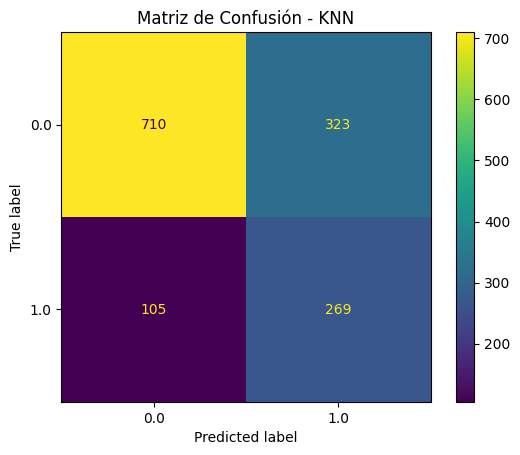

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_knn)

plt.title("Matriz de Confusión - KNN")
plt.show()

### SVM

In [ ]:
svm = SVC()

svm.fit(X_train_scaled, y_train)

pred_svm = svm.predict(X_test_scaled)

print(confusion_matrix(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

[[842 191]
 [143 231]]
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83      1033
         1.0       0.55      0.62      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407



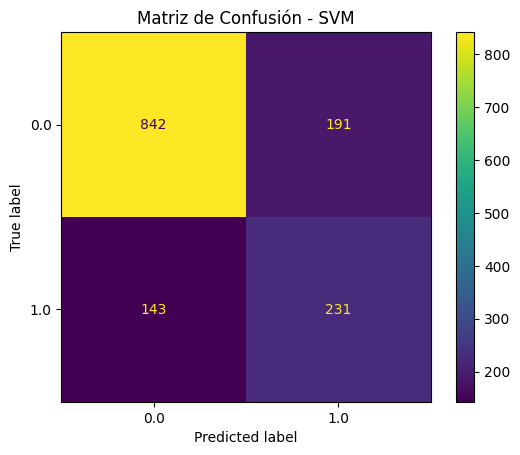

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm)

plt.title("Matriz de Confusión - SVM")
plt.show()

### Random Forest

[[920 113]
 [181 193]]
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



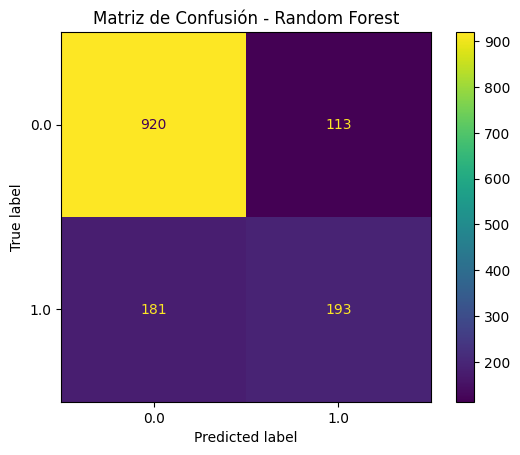

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [ ]:
#Nos quedamos con las 15 variables mas importantes
top_features = importance.head(15).index

X_train_rf = X_train[top_features]
X_test_rf = X_test[top_features]

[[911 122]
 [173 201]]
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1033
         1.0       0.62      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



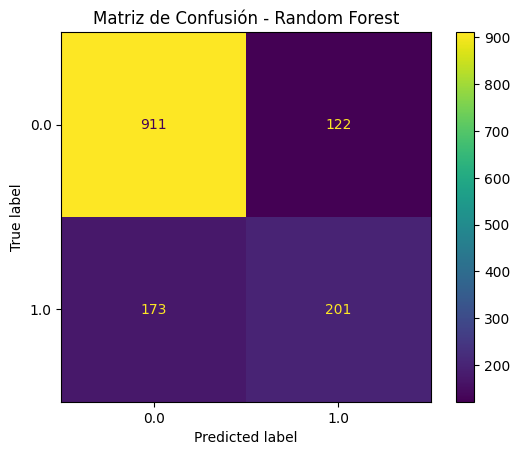

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_rf, y_train)

pred_rf = rf.predict(X_test_rf)

print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

### XGboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:30:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[893 140]
 [179 195]]
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.85      1033
         1.0       0.58      0.52      0.55       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



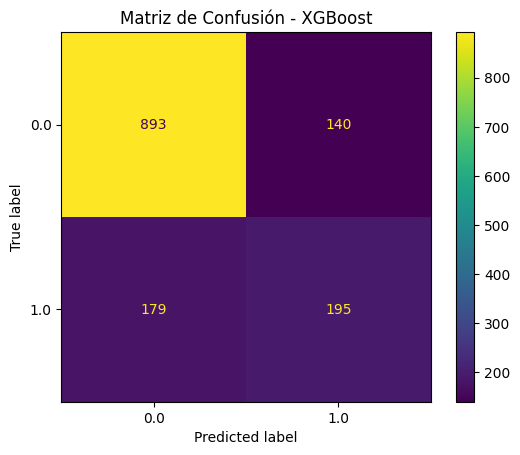

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

ConfusionMatrixDisplay.from_predictions(y_test, pred_xgb)

plt.title("Matriz de Confusión - XGBoost")
plt.show()

### XGBoost con mejores hiperparametros (f1-score)

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)

Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Mejor score: 0.8323562223516137


In [ ]:
best_xg = grid.best_estimator_

pred_xg = best_xg.predict(X_test)

In [ ]:
importance = pd.Series(
    best_xg.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

account_Contract_Month-to-month                    0.258461
internet_OnlineSecurity_Yes                        0.088710
internet_TechSupport_No                            0.084237
internet_OnlineSecurity_No                         0.064494
internet_TechSupport_Yes                           0.059981
account_PaymentMethod_Electronic check             0.045963
internet_InternetService_Fiber optic               0.030062
account_PaperlessBilling                           0.026849
customer_Partner                                   0.024754
internet_OnlineBackup_No                           0.023167
customer_SeniorCitizen                             0.022620
internet_InternetService_DSL                       0.021639
internet_OnlineBackup_Yes                          0.021290
customer_tenure                                    0.020887
phone_MultipleLines_Yes                            0.020147
account_PaymentMethod_Bank transfer (automatic)    0.016379
account_Contract_Two year               

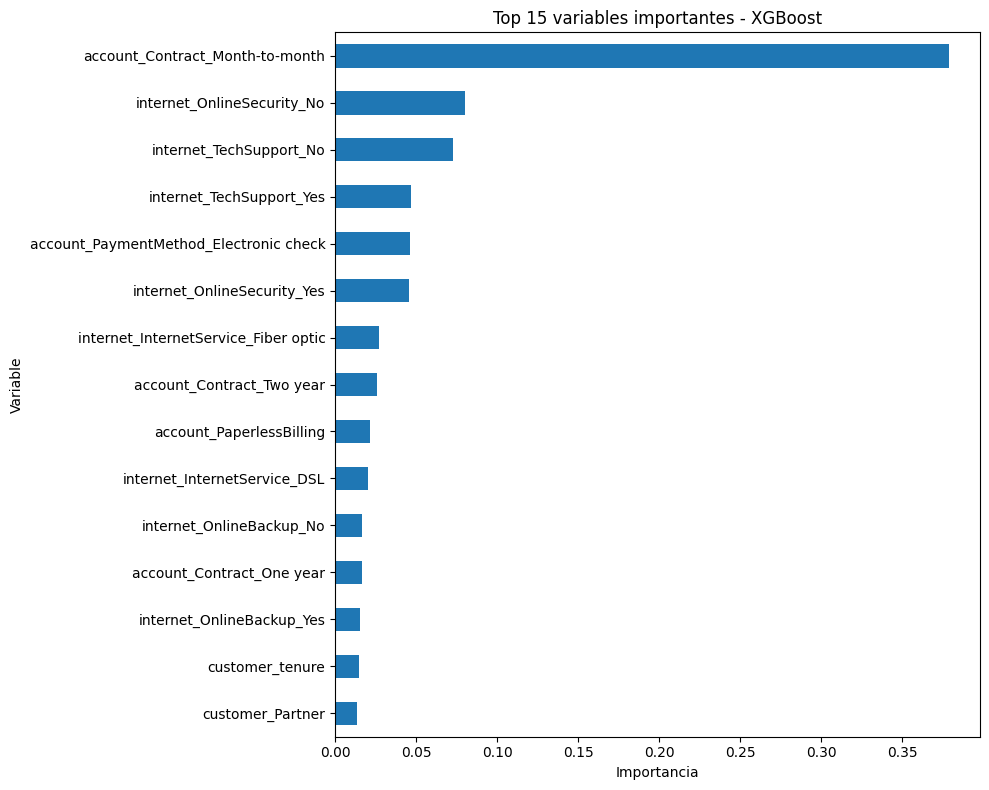

In [ ]:
importance = pd.Series(
    best_xg.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 variables importantes - XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

[[911 122]
 [173 201]]
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1033
         1.0       0.62      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



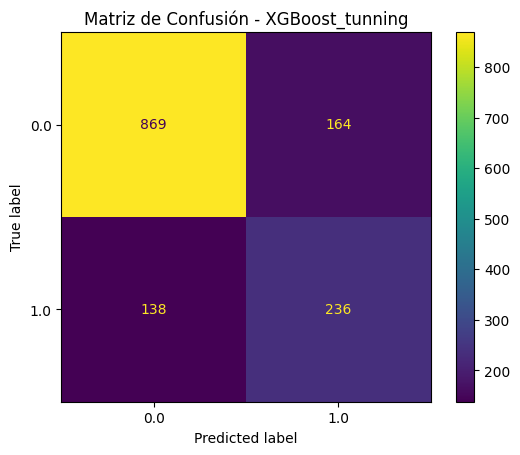

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_xg)

plt.title("Matriz de Confusión - XGBoost_tunning")
plt.show()

##Conclusión

En este trabajo se analizó el problema de cancelación de clientes (churn) utilizando distintas técnicas de aprendizaje automático. Inicialmente se realizó un análisis exploratorio de los datos con el objetivo de identificar patrones entre las variables explicativas y la variable objetivo. Se observó que variables como el tiempo de permanencia del cliente (tenure), el tipo de contrato y los cargos mensuales presentan una relación significativa con la probabilidad de cancelación.

Los modelos que utilizamos fueron:
*   k-Nearest Neighbors (kNN)
*   Support Vector Machines (SVM)
*   Logistic regression
*   Random forest
*   XGBoost

Se aplicaron diferentes técnicas de preprocesamiento, incluyendo la codificación de variables categóricas mediante one-hot encoding y el balanceo de clases utilizando SMOTE, dado que el conjunto de datos presentaba un desbalance entre clientes que cancelan y clientes que permanecen en el servicio.

Algunos modelos como K-Nearest Neighbors (KNN), Support Vector Machines (SVM) y regresión logística requieren que las variables estén en escalas comparables. Estos algoritmos dependen de distancias o combinaciones lineales de las variables, por lo que variables con mayor magnitud pueden dominar el proceso de aprendizaje. Por esta razón, en estos modelos se aplicó estandarización de las variables antes del entrenamiento. Por otro lado, los arboles de decision o ensambles de arboles como random forest y XGboost no requieren del escalado de los datos.

Tambien aprovechando que la regresion logistica es lineal en sus coeficientes utilizamos las variables que mas correlacion tienen con la variable objetivo para entrenar un modelo que solo utilice estas.

Aplicamos un Hyperparameter Tuning en XGboost y kNN para ver si lograbamos mejorar el modelo. Debido al desbalance de clases, priorizamos optimizar los modelos en terminos del f1-score en lugar del accuracy. En el análisis de las features mas importantes para XGBoost, aparecen varias que consideramos interesantes en el trabajo anterior y algunas que vimos tener una gran correlacion con churn como "account_Contract_Month-to-mont", "account_PaymentMethod_Electronic check", etc. Ademas, si XGboost se optimiza en base al accuracy, las dos caracteristicas de "customer_tenure" y "account_Charges_Total" obtienen mas importancia.

En conclusión, los resultados obtenidos entre los distintos modelos fueron muy similares. Esto indica que la estructura del problema puede ser capturada adecuadamente por modelos relativamente simples, como la regresión logística, y que el uso de modelos más complejos no produce mejoras sustanciales en el desempeño predictivo para este conjunto de datos.